# Lab 4: Model Selection and Regularization

#### Student Name: Amelia Nguyen
#### Date: March 16, 2026

In [2]:
#!pip3 install l0bnb

In [137]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from statsmodels.api import OLS
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from functools import partial
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from l0bnb import fit_path
from itertools import combinations
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

In [19]:
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)        
pd.set_option('display.max_colwidth', None) 

## Question 1: 5 multiple choice questions
Completed

## Question 2:

In [138]:
College = load_data("College")

In [139]:
College.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [140]:
College.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


### a. Best Subset Selection
Use the regsubsets() function to perform best subset selection in order to choose the best model from all 17 predictors. What is the best model obtained according to Cp, BIC, and adjusted R^2

In [141]:
np.isnan(College["Grad.Rate"]).sum()

np.int64(0)

In [142]:
College.shape

(777, 18)

In [143]:
College['Private'] = College['Private'].map({'Yes': 1, 'No': 0})

In [144]:
y = College['Grad.Rate']
X = College.drop(columns={'Grad.Rate'})
predictors = X.columns.tolist()

In [145]:
X.dtypes

Private        category
Apps              int64
Accept            int64
Enroll            int64
Top10perc         int64
Top25perc         int64
F.Undergrad       int64
P.Undergrad       int64
Outstate          int64
Room.Board        int64
Books             int64
Personal          int64
PhD               int64
Terminal          int64
S.F.Ratio       float64
perc.alumni       int64
Expend            int64
dtype: object

As `regsubsets()` does not exist in Python, and the corresponding ISLP package's `fit_path` and `l0bnb` libraries mentioned in the book's Python lab is also not compatible with newer Python version, I'll write a function to implement it using `itertools`'s package.

In [146]:
sigma2_full = sm.OLS(y, sm.add_constant(X)).fit().mse_resid

n, p = X.shape
results = []

for k in range(1, p+1):
    best_rss = np.inf
    best_subset = None
    best_model = None
    for subset in combinations(range(p), k):
        columns = list(subset)
        Xi = sm.add_constant(X.iloc[:, columns])
        model = sm.OLS(y, Xi).fit()
        model_rss = np.sum(model.resid**2)
        
        if model_rss < best_rss:
            best_rss = model_rss
            best_subset = subset
            best_model = model
    
    cp = (best_rss + 2 * (k+1) * sigma2_full) / n
    bic = best_model.bic
    
    results.append({
        'predictor_num': k,
        'subset': best_subset,
        'Cp': cp, 
        'BIC': bic,
        'adj_rsquared': best_model.rsquared_adj,
        'model': [predictors[i] for i in best_subset]})

In [147]:
summary = pd.DataFrame(results)

In [148]:
summary

,predictor_num,subset,Cp,BIC,adj_rsquared,model
0,1,"(8,)",199.350309,6329.339476,0.325503,[Outstate]
1,2,"(5, 8)",184.623459,6274.332982,0.376157,"[Top25perc, Outstate]"
2,3,"(5, 8, 15)",177.322793,6247.572786,0.401644,"[Top25perc, Outstate, perc.alumni]"
3,4,"(5, 7, 8, 15)",174.420140,6239.397896,0.412196,"[Top25perc, P.Undergrad, Outstate, perc.alumni]"
4,5,"(1, 5, 7, 8, 15)",169.864613,6223.298107,0.428420,"[Apps, Top25perc, P.Undergrad, Outstate, perc.alumni]"
5,6,"(1, 5, 7, 8, 9, 15)",167.885598,6218.743594,0.435876,"[Apps, Top25perc, P.Undergrad, Outstate, Room.Board, perc.alumni]"
6,7,"(1, 5, 7, 8, 9, 15, 16)",165.968470,6214.320729,0.443138,"[Apps, Top25perc, P.Undergrad, Outstate, Room.Board, perc.alumni, Expend]"
7,8,"(1, 5, 7, 8, 9, 11, 15, 16)",165.082765,6214.721454,0.446884,"[Apps, Top25perc, P.Undergrad, Outstate, Room.Board, Personal, perc.alumni, Expend]"
8,9,"(0, 1, 5, 7, 8, 9, 11, 15, 16)",164.465631,6216.374445,0.449717,"[Private, Apps, Top25perc, P.Undergrad, Outstate, Room.Board, Personal, perc.alumni, Expend]"
9,10,"(0, 1, 4, 5, 7, 8, 9, 11, 15, 16)",164.522895,6221.278561,0.450239,"[Private, Apps, Top10perc, Top25perc, P.Undergrad, Outstate, Room.Board, Personal, perc.alumni, Expend]"


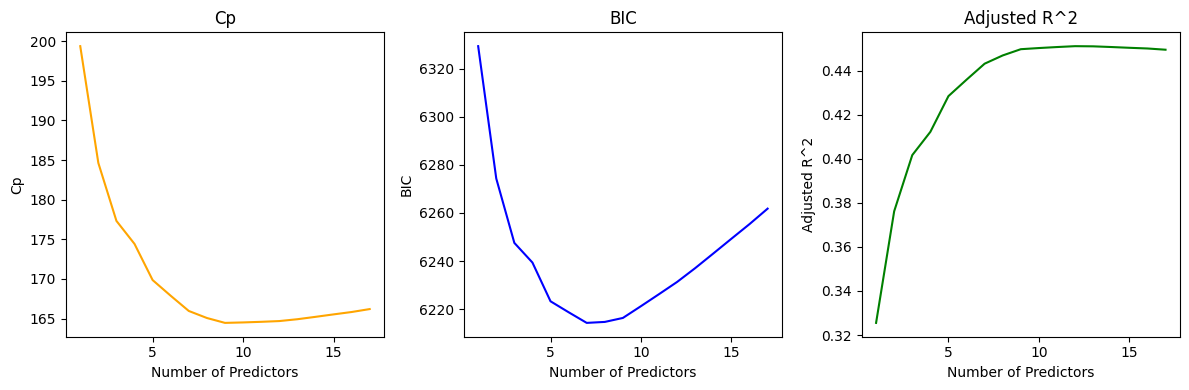

In [161]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)

axes[0].plot(summary['predictor_num'], summary['Cp'], color='orange')
axes[0].set_title('Cp')
axes[0].set_xlabel('Number of Predictors')
axes[0].set_ylabel('Cp')

axes[1].plot(summary['predictor_num'], summary['BIC'], color='blue')
axes[1].set_title('BIC')
axes[1].set_xlabel('Number of Predictors')
axes[1].set_ylabel('BIC')

axes[2].plot(summary['predictor_num'], summary['adj_rsquared'], color='green')
axes[2].set_title('Adjusted R^2')
axes[2].set_xlabel('Number of Predictors')
axes[2].set_ylabel('Adjusted R^2')

plt.tight_layout()
plt.show()

The best model obtained according to Cp, BIC, and adjusted R^2:
* Lowest Cp: 164.47 (Model 9 - 9 predictors)
* Lowest BIC: 6214.32 (Model 7 - 7 predictors)
* Lowest Adj R^2: 0.45109 (Model 12 - 12 predictors)
  
We can see from the plots, starting from model 7 (7 predictors), the curve for Cp and Adj R2 starts flattening out, while BIC hits the lowest point before increasing again at Model 9. Using the elbow method, model 7 (7 predictors) can be appropriate for optimal model choice, with lowest BIC (6214.32), low Cp (165.9), and high Adj R^2 (0.4431, only 0.8% less than Model 12 which has the highest adj R^2).

Coefficients of Model 7: [Apps, Top25perc, P.Undergrad, Outstate, Room.Board, perc.alumni, Expend]

### b. Forward Stepwise Selection
Repeat (a), using forward stepwise selection. How does your answer compare to the results in (a)?

In [11]:
sigma2_full

np.float64(162.44392729910996)

In [12]:
College['Private'] =pd.to_numeric(College['Private'])

In [15]:
n, p = X.shape

In [25]:
results_b = []

remained_predictors = list(range(p))  
selected_predictors = []             

for k in range(1, p+1):
    best_rss = np.inf
    best_candidate = None
    best_model = None
    
    for candidate in remained_predictors:
        current_predictors = selected_predictors + [candidate]
        Xi = sm.add_constant(X.iloc[:, current_predictors])
        model = sm.OLS(y, Xi).fit()
        model_rss = np.sum(model.resid**2)
        
        if model_rss < best_rss:
            best_rss = model_rss
            best_candidate = candidate
            best_model = model
    
    selected_predictors.append(best_candidate)
    remained_predictors.remove(best_candidate)
    
    cp = (best_rss + 2 * (len(selected_predictors)+1) * sigma2_full) / n
    bic = best_model.bic
    
    results_b.append({
        'predictor_num': k,
        'subset': selected_predictors.copy(),
        'Cp': cp,
        'BIC': bic,
        'adj_rsquared': best_model.rsquared_adj,
        'model': [predictors[i] for i in selected_predictors]})

In [26]:
summary_b = pd.DataFrame(results_b)

In [27]:
summary_b

,predictor_num,subset,Cp,BIC,adj_rsquared,model
0,1,[8],199.350309,6329.339476,0.325503,[Outstate]
1,2,"[8, 5]",184.623459,6274.332982,0.376157,"[Outstate, Top25perc]"
2,3,"[8, 5, 15]",177.322793,6247.572786,0.401644,"[Outstate, Top25perc, perc.alumni]"
3,4,"[8, 5, 15, 7]",174.420140,6239.397896,0.412196,"[Outstate, Top25perc, perc.alumni, P.Undergrad]"
4,5,"[8, 5, 15, 7, 1]",169.864613,6223.298107,0.428420,"[Outstate, Top25perc, perc.alumni, P.Undergrad, Apps]"
5,6,"[8, 5, 15, 7, 1, 9]",167.885598,6218.743594,0.435876,"[Outstate, Top25perc, perc.alumni, P.Undergrad, Apps, Room.Board]"
6,7,"[8, 5, 15, 7, 1, 9, 16]",165.968470,6214.320729,0.443138,"[Outstate, Top25perc, perc.alumni, P.Undergrad, Apps, Room.Board, Expend]"
7,8,"[8, 5, 15, 7, 1, 9, 16, 11]",165.082765,6214.721454,0.446884,"[Outstate, Top25perc, perc.alumni, P.Undergrad, Apps, Room.Board, Expend, Personal]"
8,9,"[8, 5, 15, 7, 1, 9, 16, 11, 0]",164.465631,6216.374445,0.449717,"[Outstate, Top25perc, perc.alumni, P.Undergrad, Apps, Room.Board, Expend, Personal, Private]"
9,10,"[8, 5, 15, 7, 1, 9, 16, 11, 0, 4]",164.522895,6221.278561,0.450239,"[Outstate, Top25perc, perc.alumni, P.Undergrad, Apps, Room.Board, Expend, Personal, Private, Top10perc]"


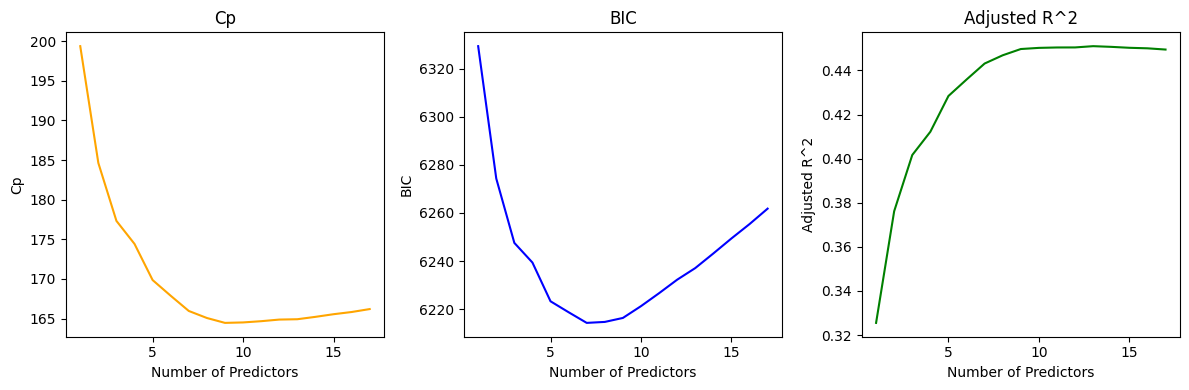

In [160]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)

axes[0].plot(summary_b['predictor_num'], summary_b['Cp'], color='orange')
axes[0].set_title('Cp')
axes[0].set_xlabel('Number of Predictors')
axes[0].set_ylabel('Cp')

axes[1].plot(summary_b['predictor_num'], summary_b['BIC'], color='blue')
axes[1].set_title('BIC')
axes[1].set_xlabel('Number of Predictors')
axes[1].set_ylabel('BIC')

axes[2].plot(summary_b['predictor_num'], summary_b['adj_rsquared'], color='green')
axes[2].set_title('Adjusted R^2')
axes[2].set_xlabel('Number of Predictors')
axes[2].set_ylabel('Adjusted R^2')

plt.tight_layout()
plt.show()

The best model in this section is also Model 7 (7 predictors). 

From the plot, we can see that:
* Model 9 has lowest Cp
* Model 7 has lowest BIC
* Model 13 has highest adj R^2

Similar to section (a), we also choose Model 7 with the same reason.

* Model 7 from (a): 1, 5, 7, 8, 9, 11, 15, 16) (Apps, Top25perc, P.Undergrad, Outstate, Room.Board, Personal, perc.alumni, Expend)
* Model 7 from (b): 8, 5, 15, 7, 1, 9, 16, 11	(Outstate, Top25perc, perc.alumni, P.Undergrad, Apps, Room.Board, Expend, Personal)

=> Both has similar result. We can see that Stepwise Selection can derive similar result to Best Subset Selection with much more efficient performance.

## Question 3:
### a. Lambda grid
Please implement a function over a grid of values ranging from λ=0.01 to 10^10, the length = 200, between any two neighboring λ values. Please print the first 15 λ values.

In [29]:
College = load_data("College")

In [41]:
lambda_grid = np.logspace(-2, 10, num=200)
print(lambda_grid[:15])

[0.01       0.01148951 0.01320088 0.01516717 0.01742633 0.020022
 0.0230043  0.02643081 0.03036771 0.03489101 0.04008806 0.04605922
 0.05291979 0.06080224 0.0698588 ]


### b. Split the data set into a training set (90%) and a test set (10%)

In [ ]:
X = College.drop(columns={'Grad.Rate'})
y = College['Grad.Rate']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 16)

In [37]:
X_train.shape

(699, 17)

In [38]:
X_test.shape

(78, 17)

### c. Lasso CV
Fit a Lasso model on the training, and apply the 10 fold cross validation procedure to search the best value of 𝜆, which is corresponding to the smallest error rate. Draw the graph to show the trend between MSE and 𝜆

In [40]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [44]:
print(lambda_grid[:15])

[0.01       0.01148951 0.01320088 0.01516717 0.01742633 0.020022
 0.0230043  0.02643081 0.03036771 0.03489101 0.04008806 0.04605922
 0.05291979 0.06080224 0.0698588 ]


In [73]:
lasso_cv = LassoCV(
    alphas=lambda_grid,
    cv=10,
    random_state=10)

lasso_cv.fit(X_train_scale, y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,array([1.0000...00000000e+10])
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,10
,verbose,False
,n_jobs,None


In [74]:
lasso_cv.alpha_

np.float64(0.2800503894183631)

In [75]:
print(f"Best value for lambda is {lasso_cv.alpha_}")

Best value for lambda is 0.2800503894183631


In [78]:
np.log10(lasso_cv.alpha_)

np.float64(-0.5527638190954773)

chosen lambda = 10^(-0.5528) = 0.28

In [76]:
np.min(lasso_cv.mse_path_.mean(1))

np.float64(162.40850466782223)

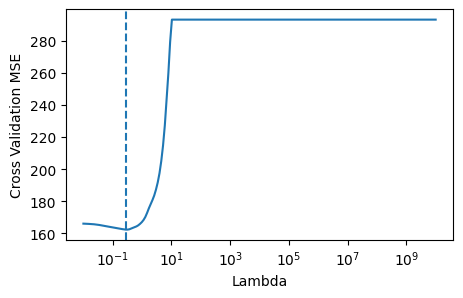

In [158]:
plt.figure(figsize=(5,3))
plt.semilogx(lasso_cv.alphas_, lasso_cv.mse_path_.mean(1))

plt.axvline(best_lambda, linestyle='--')
plt.xlabel("Lambda")
plt.ylabel("Cross Validation MSE")
plt.show()

### d. Lasso test
Apply the training Lasso regression model result and the best 𝜆 value to the test data set. Please calculate the test mean square error, and output the regression coefficients of the final selected model.

In [83]:
y_pred = lasso_cv.predict(X_test_scale)

In [84]:
test_mse = mean_squared_error(y_test, y_pred)

In [85]:
test_mse

200.67095163226045

In [86]:
output = pd.DataFrame({'Predictors': X_train.columns, 'Coefficient': lasso_cv.coef_})

In [87]:
output

,Predictors,Coefficient
0,Private,0.980139
1,Apps,2.728394
2,Accept,0.000000
3,Enroll,-0.000000
4,Top10perc,1.053209
5,Top25perc,2.332791
6,F.Undergrad,-0.000000
7,P.Undergrad,-2.206748
8,Outstate,3.410700
9,Room.Board,1.907401


## Question 4:
### a. PCA
Fit a PCA model on the training set, and select the appropriate number of components (k) by cross-validation. Report the test error obtained, along with the value of k selected by cross-validation.

In [94]:
X_train_scale.shape

(699, 17)

In [95]:
n, p = X_train_scale.shape

In [115]:
cv_mse = []
for k in range(1, p+1):
    pca = PCA(n_components=k)
    X_train_pca = pca.fit_transform(X_train_scale)
    model = LinearRegression()
    score = cross_val_score(model,X_train_pca, y_train, cv=10, scoring='neg_mean_squared_error')
    cv_mse.append({'k': k,
                  'mse': -score.mean()})

In [151]:
cv_mse = pd.DataFrame(cv_mse)
cv_mse.sort_values(by='mse', ascending=True).head(5)

,k,mse
11,12,163.571208
10,11,164.538589
8,9,164.867658
12,13,165.207476
13,14,165.307493


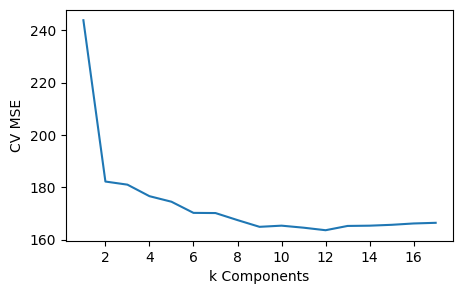

In [156]:
plt.figure(figsize=(5,3))
plt.plot(cv_mse['k'], cv_mse['mse'])
plt.xlabel("k Components")
plt.ylabel("CV MSE")
plt.show()

k = 12 has the lowest MSE in 10-fold cross validation, with the Cross Validation MSE at 163.571208

In [118]:
pca_final = PCA(n_components=12)
X_train_pca = pca_final.fit_transform(X_train_scale)
X_test_pca = pca_final.transform(X_test_scale)
model_final = LinearRegression()
model_final.fit(X_train_pca, y_train)
y_pred = model_final.predict(X_test_pca)
test_mse = mean_squared_error(y_test, y_pred)

In [119]:
print(f"Test MSE of PCA with 12 components is {test_mse}")

Test MSE of PCA with 12 components is 199.16985762186434


### b. PLS
Fit a PLS model on the training set, and select the appropriate number of components (k) by cross-validation. Report the test error obtained, along with the value of k selected by cross- validation.


In [132]:
pls_cv_mse = []
for k in range(1, p+1):
    pls = PLSRegression(n_components=k)
    score = cross_val_score(pls, X_train_scale, y_train, cv=10, scoring='neg_mean_squared_error')
    pls_cv_mse.append({'k': k,
                  'mse': -score.mean()})

In [152]:
pls_cv_mse = pd.DataFrame(pls_cv_mse)
pls_cv_mse.sort_values(by='mse', ascending=True).head(5)

,k,mse
3,4,163.621185
4,5,164.135566
2,3,164.383111
5,6,164.992412
6,7,165.401551


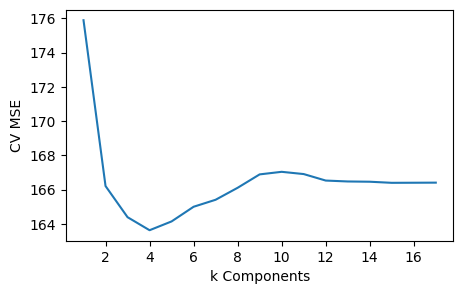

In [155]:
plt.figure(figsize=(5,3))
plt.plot(pls_cv_mse['k'], pls_cv_mse['mse'])
plt.xlabel("k Components")
plt.ylabel("CV MSE")
plt.show()

k = 4 has the lowest CV MSE at 163.62

In [136]:
pls_final = PLSRegression(n_components=4)
pls_final.fit(X_train_scale, y_train)

y_pred = pls_final.predict(X_test_scale)
pls_test_mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE of PLS with 4 components is {pls_test_mse}")

Test MSE of PLS with 4 components is 199.7977141697895
